# Fase 7 — Generalizzazione

**Ipotesi H3**: le prestazioni crollano fuori dominio.

La Fase 6 ha mostrato *come* il modello sbaglia dentro il proprio dominio.
Qui si verifica se quello che ha imparato vale altrove.

Previsione registrata in Fase 5: **TF-IDF dovrebbe crollare piu' del
modello stilometrico**, perche' in-domain si appoggia anche al lessico
tematico. L'evidenza a supporto viene dalla Fase 3: il token `financial`
discriminava le classi solo dentro il dominio finance, mentre `important`
manteneva il divario in tutti e quattro i domini.

Tre analisi:

1. **Leave-one-domain-out** — quattro esperimenti, ognuno addestra su tre
   domini e testa sul quarto.
2. **Analisi di sensibilita'** — la pipeline rieseguita a tolleranze di
   appaiamento diverse, per verificare che le conclusioni non dipendano dal
   parametro. Si riportano tutte le righe, non la migliore.
3. **Post-editing** — quanto basta ritoccare un testo generato perche' il
   modello lo classifichi come umano.

## 0. Setup

In [1]:
import sys
import importlib.util
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RADICE = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
FIGURE = RADICE / "results" / "figures"
TABELLE = RADICE / "results" / "tables"

SEED = 42
plt.rcParams["figure.dpi"] = 110
plt.rcParams["font.size"] = 10


def carica_modulo(nome_file: str, alias: str):
    percorso = RADICE / "src" / nome_file
    if not percorso.exists():
        candidati = sorted(p.name for p in (RADICE / "src").glob("*.py"))
        raise FileNotFoundError(f"{nome_file} non trovato. In src/: {candidati}")
    spec = importlib.util.spec_from_file_location(alias, percorso)
    modulo = importlib.util.module_from_spec(spec)
    sys.modules[alias] = modulo
    spec.loader.exec_module(modulo)
    return modulo


M = carica_modulo("models.py", "modelli")
E = carica_modulo("evaluation.py", "valutazione")

df = pd.read_parquet(RADICE / "data" / "processed" / "hc3_features.parquet")
COLS = M.colonne_feature(df)
print(f"{len(df)} righe, {len(COLS)} feature, domini: {sorted(df.domain.unique())}")

19980 righe, 30 feature, domini: ['finance', 'medicine', 'reddit_eli5', 'wiki_csai']


## 1. Riferimento in-domain

Le metriche della Fase 5, ricalcolate qui per avere il termine di paragone
nello stesso notebook.

In [2]:
train_completo, test = M.split_per_domanda(df, test_size=0.25)
train, valid = M.split_per_domanda(train_completo, test_size=0.20)

stilo = M.modello_stilometrico()
stilo.fit(train[COLS], train["label"])
rif_stilo = E.valuta(
    test["label"], stilo.predict(test[COLS]),
    stilo.predict_proba(test[COLS])[:, 1], nome="stilometrico in-domain",
)

tfidf = M.modello_tfidf()
tfidf.fit(train["text"], train["label"])
rif_tfidf = E.valuta(
    test["label"], tfidf.predict(test["text"]),
    tfidf.predict_proba(test["text"])[:, 1], nome="tfidf in-domain",
)

riferimento = pd.DataFrame([rif_stilo, rif_tfidf])
riferimento[["modello", "accuracy", "fpr", "auroc"]].round(4)

,modello,accuracy,fpr,auroc
0,stilometrico in-domain,0.9191,0.0789,0.9707
1,tfidf in-domain,0.9708,0.0264,0.9962


## 2. Leave-one-domain-out

Ogni dominio a turno diventa test set, i restanti tre il training set. Non
serve split per `question_id`: i domini sono disgiunti per costruzione,
quindi nessuna coppia puo' finire divisa.

Nota sull'asimmetria dei fold: `reddit_eli5` e' il 70% del corpus. Il fold
che lo esclude addestra su circa 6.000 righe e ne testa quasi 14.000, ed e'
il caso piu' informativo — il modello deve generalizzare da domini
specialistici a scrittura divulgativa informale.

In [3]:
righe = []
for dominio in sorted(df["domain"].unique()):
    tr = df[df["domain"] != dominio]
    te = df[df["domain"] == dominio]

    m_s = M.modello_stilometrico()
    m_s.fit(tr[COLS], tr["label"])
    r_s = E.valuta(te["label"], m_s.predict(te[COLS]),
                   m_s.predict_proba(te[COLS])[:, 1], nome="stilometrico")
    r_s.update({"dominio_test": dominio, "n_train": len(tr), "n_test": len(te)})
    righe.append(r_s)

    m_t = M.modello_tfidf()
    m_t.fit(tr["text"], tr["label"])
    r_t = E.valuta(te["label"], m_t.predict(te["text"]),
                   m_t.predict_proba(te["text"])[:, 1], nome="tfidf")
    r_t.update({"dominio_test": dominio, "n_train": len(tr), "n_test": len(te)})
    righe.append(r_t)

    print(f"{dominio}: fatto")

fuori_dominio = pd.DataFrame(righe)
fuori_dominio["delta_auroc"] = np.where(
    fuori_dominio["modello"] == "stilometrico",
    fuori_dominio["auroc"] - rif_stilo["auroc"],
    fuori_dominio["auroc"] - rif_tfidf["auroc"],
)
fuori_dominio.to_csv(TABELLE / "generalizzazione_dominio.csv", index=False)

fuori_dominio[["dominio_test", "modello", "n_test", "accuracy",
               "fpr", "auroc", "delta_auroc"]].round(4)

finance: fatto
medicine: fatto
reddit_eli5: fatto
wiki_csai: fatto


,dominio_test,modello,n_test,accuracy,fpr,auroc,delta_auroc
0,finance,stilometrico,4058,0.9189,0.1178,0.9736,0.0029
1,finance,tfidf,4058,0.9776,0.0128,0.9978,0.0016
2,medicine,stilometrico,878,0.9533,0.0273,0.9872,0.0165
3,medicine,tfidf,878,0.9636,0.0729,0.9998,0.0037
4,reddit_eli5,stilometrico,13968,0.8632,0.0461,0.9493,-0.0214
5,reddit_eli5,tfidf,13968,0.7272,0.0020,0.9454,-0.0508
6,wiki_csai,stilometrico,1076,0.7816,0.4033,0.9078,-0.0629
7,wiki_csai,tfidf,1076,0.7463,0.4684,0.9231,-0.0731


### La tabella che va in slide

`delta_auroc` e' il risultato: quanto si perde uscendo dal dominio di
addestramento.

In [4]:
pivot = fuori_dominio.pivot(index="dominio_test", columns="modello",
                            values="auroc").round(4)
pivot.loc["-- in-domain --"] = [rif_stilo["auroc"], rif_tfidf["auroc"]]
pivot

modello,stilometrico,tfidf
dominio_test,,
finance,0.973600,0.997800
medicine,0.987200,0.999800
reddit_eli5,0.949300,0.945400
wiki_csai,0.907800,0.923100
-- in-domain --,0.970693,0.996176


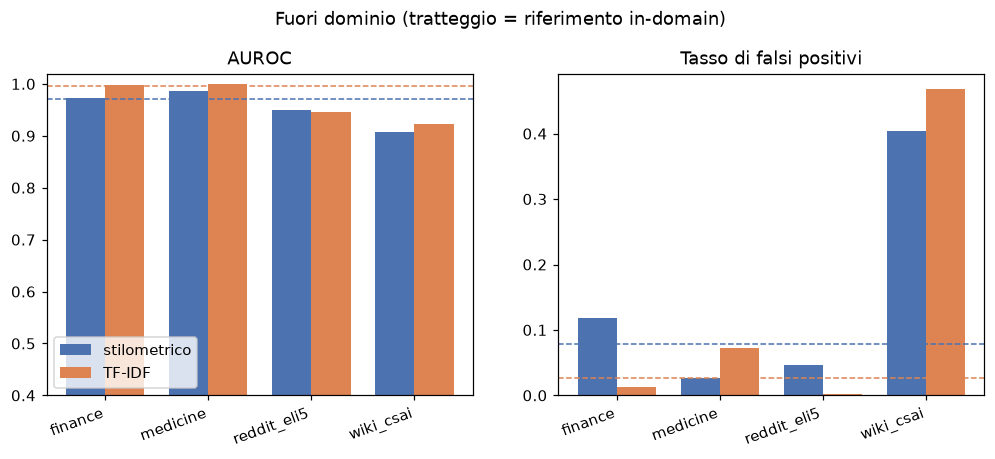

In [5]:
fig, assi = plt.subplots(1, 2, figsize=(11, 3.8))

domini = sorted(df["domain"].unique())
x = np.arange(len(domini))
larghezza = 0.38

for ax, metrica, riferimenti, titolo in [
    (assi[0], "auroc", (rif_stilo["auroc"], rif_tfidf["auroc"]), "AUROC"),
    (assi[1], "fpr", (rif_stilo["fpr"], rif_tfidf["fpr"]),
     "Tasso di falsi positivi"),
]:
    s = fuori_dominio[fuori_dominio["modello"] == "stilometrico"] \
        .set_index("dominio_test").loc[domini, metrica]
    t = fuori_dominio[fuori_dominio["modello"] == "tfidf"] \
        .set_index("dominio_test").loc[domini, metrica]
    ax.bar(x - larghezza / 2, s, larghezza, label="stilometrico", color="#4C72B0")
    ax.bar(x + larghezza / 2, t, larghezza, label="TF-IDF", color="#DD8452")
    ax.axhline(riferimenti[0], color="#4C72B0", linestyle="--", linewidth=1)
    ax.axhline(riferimenti[1], color="#DD8452", linestyle="--", linewidth=1)
    ax.set_xticks(x)
    ax.set_xticklabels(domini, rotation=20, ha="right")
    ax.set_title(titolo)

assi[0].set_ylim(0.4, 1.02)
assi[0].legend(loc="lower left")
fig.suptitle("Fuori dominio (tratteggio = riferimento in-domain)", y=1.03)
fig.savefig(FIGURE / "12_generalizzazione.png", dpi=150, bbox_inches="tight")
plt.show()

### Verifica della previsione

La previsione era: TF-IDF perde piu' del modello stilometrico. Qui si
misura il calo medio dei due.

In [6]:
calo = fuori_dominio.groupby("modello").agg(
    auroc_media_fuori=("auroc", "mean"),
    fpr_medio_fuori=("fpr", "mean"),
)
calo["auroc_in_domain"] = [rif_stilo["auroc"], rif_tfidf["auroc"]]
calo.loc["stilometrico", "auroc_in_domain"] = rif_stilo["auroc"]
calo.loc["tfidf", "auroc_in_domain"] = rif_tfidf["auroc"]
calo["calo_auroc"] = calo["auroc_in_domain"] - calo["auroc_media_fuori"]
calo.round(4)

,auroc_media_fuori,fpr_medio_fuori,auroc_in_domain,calo_auroc
modello,,,,
stilometrico,0.9545,0.1486,0.9707,0.0162
tfidf,0.9665,0.1390,0.9962,0.0297


## 3. Analisi di sensibilita'

La tolleranza di appaiamento 0.50 e' stata scelta a priori (vedi CLAUDE.md).
Qui si verifica che le conclusioni non dipendano da quel valore.

**Non si sceglie la configurazione migliore**: si riportano tutte le righe.
Se H2 e H3 reggono ovunque, il risultato e' robusto; se non reggono, quello
e' il risultato.

Richiede di rigenerare corpus e feature per ogni tolleranza. Costoso in
tempo (circa 4 minuti per condizione), quindi conviene lanciarlo una volta
sola e salvare.

In [7]:
C = carica_modulo("4_cleaning.py", "pulizia")
F = carica_modulo("features.py", "caratteristiche")

TOLLERANZE = [0.30, 0.40, 0.50, None]
RIGENERA = True   # False per rileggere la tabella gia' salvata

percorso_sensibilita = TABELLE / "sensibilita_tolleranza.csv"

if RIGENERA:
    risultati = []
    for tol in TOLLERANZE:
        etichetta = f"{tol}" if tol is not None else "nessuna"
        print(f"--- tolleranza {etichetta}")
        temporaneo = RADICE / "data" / "processed" / f"tmp_tol_{etichetta}.parquet"
        pulito = C.pulisci(percorso_out=temporaneo, tolleranza=tol)
        con_feature = F.estrai_tutte(pulito)
        con_feature = con_feature.dropna(subset=["mattr"])

        tr_c, te = M.split_per_domanda(con_feature, test_size=0.25)
        tr, _ = M.split_per_domanda(tr_c, test_size=0.20)
        m = M.modello_stilometrico()
        m.fit(tr[COLS], tr["label"])
        r = E.valuta(te["label"], m.predict(te[COLS]),
                     m.predict_proba(te[COLS])[:, 1], nome=etichetta)
        r["tolleranza"] = etichetta
        r["n_coppie"] = con_feature["question_id"].nunique()

        # H2 regge? Confronto su mattr fra falsi positivi e veri negativi.
        te = te.copy()
        te["pred"] = m.predict(te[COLS])
        um = te[te["label"] == 0]
        fp = um[um["pred"] == 1]
        vn = um[um["pred"] == 0]
        r["mattr_FP"] = fp["mattr"].mean()
        r["mattr_VN"] = vn["mattr"].mean()
        r["H2_direzione_attesa"] = bool(fp["mattr"].mean() < vn["mattr"].mean())
        risultati.append(r)
        temporaneo.unlink(missing_ok=True)

    sensibilita = pd.DataFrame(risultati)
    sensibilita.to_csv(percorso_sensibilita, index=False)
else:
    sensibilita = (pd.read_csv(percorso_sensibilita)
                   if percorso_sensibilita.exists() else None)
    if sensibilita is None:
        print("Non ancora eseguita: mettere RIGENERA = True")

if sensibilita is not None:
    display(sensibilita[["tolleranza", "n_coppie", "accuracy", "fpr", "auroc",
                         "mattr_FP", "mattr_VN", "H2_direzione_attesa"]].round(4))

--- tolleranza 0.3
Partenza: 47730 righe, 5 domini
Esclusi ['open_qa']: restano 45356 righe
Filtro lunghezza [50-600]: tengo 38848 su 45356
Appaiamento lunghezze (tolleranza 0.3): tengo 10794 su 38848
Salvate 10794 righe (5397 coppie) in /Users/costanzastassi/Desktop/mgt-stylometry/data/processed/tmp_tol_0.3.parquet


Estrazione feature: 100%|██████████| 10794/10794 [07:28<00:00, 24.06it/s]


--- tolleranza 0.4
Partenza: 47730 righe, 5 domini
Esclusi ['open_qa']: restano 45356 righe
Filtro lunghezza [50-600]: tengo 38848 su 45356
Appaiamento lunghezze (tolleranza 0.4): tengo 15170 su 38848
Salvate 15170 righe (7585 coppie) in /Users/costanzastassi/Desktop/mgt-stylometry/data/processed/tmp_tol_0.4.parquet


Estrazione feature: 100%|██████████| 15170/15170 [11:14<00:00, 22.48it/s]


--- tolleranza 0.5
Partenza: 47730 righe, 5 domini
Esclusi ['open_qa']: restano 45356 righe
Filtro lunghezza [50-600]: tengo 38848 su 45356
Appaiamento lunghezze (tolleranza 0.5): tengo 19980 su 38848
Salvate 19980 righe (9990 coppie) in /Users/costanzastassi/Desktop/mgt-stylometry/data/processed/tmp_tol_0.5.parquet


Estrazione feature: 100%|██████████| 19980/19980 [14:12<00:00, 23.44it/s]


--- tolleranza nessuna
Partenza: 47730 righe, 5 domini
Esclusi ['open_qa']: restano 45356 righe
Filtro lunghezza [50-600]: tengo 38848 su 45356
Salvate 38848 righe (22629 coppie) in /Users/costanzastassi/Desktop/mgt-stylometry/data/processed/tmp_tol_nessuna.parquet


Estrazione feature: 100%|██████████| 38848/38848 [43:00<00:00, 15.05it/s]    


,tolleranza,n_coppie,accuracy,fpr,auroc,mattr_FP,mattr_VN,H2_direzione_attesa
0,0.3,5397,0.9115,0.1022,0.9663,0.6116,0.6829,True
1,0.4,7585,0.9188,0.0928,0.9687,0.6182,0.6891,True
2,0.5,9990,0.9191,0.0789,0.9707,0.6151,0.6889,True
3,nessuna,22629,0.9267,0.1011,0.9746,0.6188,0.7091,True


### Risultato dell'analisi di sensibilita'

Dalla tabella `results/tables/sensibilita_tolleranza.csv`:

| tolleranza | coppie | accuracy | FPR | AUROC | mattr FP | mattr VN | H2 nella direzione attesa |
|-----------:|-------:|---------:|----:|------:|---------:|---------:|:---:|
| 0.30 | 5.397 | 0.911 | 0.102 | 0.966 | 0.612 | 0.683 | si' |
| 0.40 | 7.585 | 0.919 | 0.093 | 0.969 | 0.618 | 0.689 | si' |
| **0.50** | **9.990** | **0.919** | **0.079** | **0.971** | **0.615** | **0.689** | **si'** |
| nessuna | 22.629 | 0.927 | 0.101 | 0.975 | 0.619 | 0.709 | si' |

L'AUROC oscilla di meno di 0.01 su campioni che vanno da 5.397 a 22.629
coppie, e H2 mantiene la direzione attesa in tutte le condizioni: le
conclusioni non dipendono dalla tolleranza fissata a priori. Senza
appaiamento l'AUROC e' la piu' alta, ma il tasso di falsi positivi peggiora
rispetto alla condizione principale.

## 4. Post-editing

Quanto basta ritoccare un testo generato perche' il modello cambi idea?

Due varianti. La prima e' **automatica e sistematica**: si applicano
trasformazioni meccaniche a tutti i testi generati del test set, e si misura
il calo di recall. Non e' post-editing realistico, ma e' riproducibile e
quantificabile.

La seconda e' **manuale su 30 casi**, piu' realistica ma da presentare come
esemplificazione qualitativa: con 30 osservazioni non si sostengono
conclusioni statistiche, e dirlo prima che lo chieda il docente e' un punto
a favore.

In [8]:
import re

RE_FRASE_LUNGA = re.compile(r"(\w{4,}), (and|but|which|that) ")


def spezza_frasi(t: str) -> str:
    """Sostituisce alcune coordinazioni con punti fermi."""
    return RE_FRASE_LUNGA.sub(r"\1. ", t)


def togli_connettivi(t: str) -> str:
    for parola in ["However, ", "Moreover, ", "Additionally, ", "Overall, ",
                   "Furthermore, ", "Therefore, ", "It is important to note that ",
                   "It's important to note that "]:
        t = t.replace(parola, "")
    return t


def aggiungi_contrazioni(t: str) -> str:
    for lungo, breve in [("do not", "don't"), ("does not", "doesn't"),
                         ("it is", "it's"), ("that is", "that's"),
                         ("you are", "you're"), ("cannot", "can't"),
                         ("will not", "won't"), ("is not", "isn't")]:
        t = t.replace(lungo, breve)
    return t


TRASFORMAZIONI = {
    "originale": lambda t: t,
    "spezza frasi": spezza_frasi,
    "togli connettivi": togli_connettivi,
    "aggiungi contrazioni": aggiungi_contrazioni,
    "tutte insieme": lambda t: aggiungi_contrazioni(
        togli_connettivi(spezza_frasi(t))),
}

In [9]:
generati = test[test["label"] == 1].copy()
print(f"Testi generati nel test set: {len(generati)}")

righe = []
for nome, funzione in TRASFORMAZIONI.items():
    modificati = generati["text"].map(funzione)
    nuove_feature = pd.DataFrame([F.estrai(t) for t in modificati])
    nuove_feature = nuove_feature.reindex(columns=COLS)
    validi = nuove_feature.notna().all(axis=1)

    pred = stilo.predict(nuove_feature[validi])
    prob = stilo.predict_proba(nuove_feature[validi])[:, 1]

    righe.append({
        "trasformazione": nome,
        "n_valutati": int(validi.sum()),
        "riconosciuti": int(pred.sum()),
        "recall": float(pred.mean()),
        "prob_media": float(prob.mean()),
    })
    print(f"{nome}: recall {pred.mean():.3f}")

postediting = pd.DataFrame(righe)
postediting["calo_recall"] = (
    postediting.loc[0, "recall"] - postediting["recall"]
)
postediting.to_csv(TABELLE / "postediting_automatico.csv", index=False)
postediting.round(4)

Testi generati nel test set: 2498
originale: recall 0.917
spezza frasi: recall 0.769
togli connettivi: recall 0.903
aggiungi contrazioni: recall 0.914
tutte insieme: recall 0.738


,trasformazione,n_valutati,riconosciuti,recall,prob_media,calo_recall
0,originale,2498,2291,0.9171,0.8660,0.0000
1,spezza frasi,2498,1920,0.7686,0.7213,0.1485
2,togli connettivi,2498,2255,0.9027,0.8516,0.0144
3,aggiungi contrazioni,2498,2284,0.9143,0.8636,0.0028
4,tutte insieme,2498,1844,0.7382,0.6921,0.1789


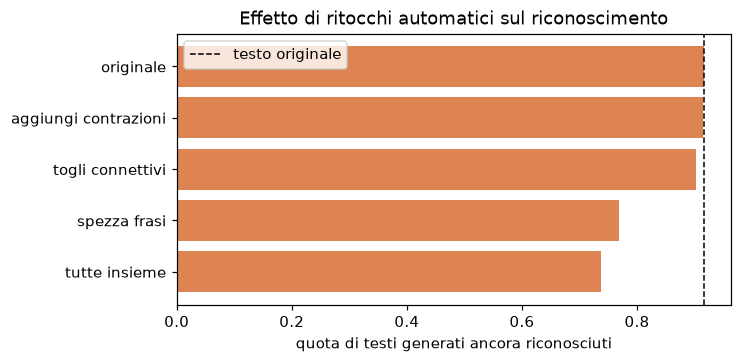

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 3.2))
ordinati = postediting.sort_values("recall")
ax.barh(ordinati["trasformazione"], ordinati["recall"], color="#DD8452")
ax.axvline(postediting.loc[0, "recall"], color="black",
           linestyle="--", linewidth=1, label="testo originale")
ax.set_xlabel("quota di testi generati ancora riconosciuti")
ax.set_title("Effetto di ritocchi automatici sul riconoscimento")
ax.legend()
fig.savefig(FIGURE / "13_postediting.png", dpi=150, bbox_inches="tight")
plt.show()

### Post-editing manuale

Non svolto. Il post-editing automatico della sezione precedente e'
riproducibile e riguarda tutti i 2.498 testi generati del test set; una
riscrittura a mano di pochi casi sarebbe stata solo un esempio qualitativo.

## 5. Test esterno

Non svolto. M4GT-Bench non e' caricabile direttamente da HuggingFace: e'
distribuito dal repository GitHub `mbzuai-nlp/M4GT-Bench` con formati propri,
e il suo adattamento avrebbe richiesto un tempo non compatibile con la
consegna.

La generalizzazione e' quindi verificata fra domini ma non fra generatori ne'
fra lingue: i testi di HC3 provengono tutti da ChatGPT (dicembre 2022). Il
limite e' dichiarato nel README. L'osservazione della Fase 4 sull'em dash,
oggi considerato un marcatore del testo generato e in HC3 molto piu'
frequente nei testi umani, suggerisce che i tratti stilistici cambino fra
generazioni di modelli.

## 6. Conclusioni

Risposte, scritte dopo aver guardato i risultati.

In [ ]:
conclusioni = """
1. H3, nella formulazione originale, e' smentita. L'AUROC non crolla: resta
   sopra 0.90 su tutti i domini, con un calo medio di 0.016 rispetto
   all'in-domain (0.971). Cio' che non si trasferisce e' la soglia di
   decisione, non la capacita' di ordinare i testi.

2. In media TF-IDF perde piu' AUROC (0.030 contro 0.016 dello stilometrico),
   come previsto, ma le differenze sono piccole. La differenza vera sta nei
   falsi positivi: TF-IDF raggiunge il 47% su wiki_csai e, su reddit_eli5,
   classifica quasi tutto come umano (recall 0.46).

3. Il tasso di falsi positivi fuori dominio varia dallo 0.2% al 47% (7.9%
   in-domain per lo stilometrico). Su wiki_csai il modello stilometrico
   accusa il 40% dei testi umani.

4. wiki_csai e' il dominio piu' difficile: voci enciclopediche, prosa
   impersonale ed editata, che il modello associa alla macchina. E' lo stesso
   dominio con piu' falsi positivi anche in-domain (19.9%).

5. Si'. Al variare della tolleranza (0.30, 0.40, 0.50, nessuna) l'AUROC
   oscilla di meno di 0.01 e H2 regge in tutte le condizioni.

6. Poco: tre sostituzioni meccaniche (spezzare le frasi lunghe, togliere i
   connettivi, aggiungere le contrazioni) portano il riconoscimento dal 92% al
   74%. La sola rottura delle frasi lunghe vale quasi 15 punti.

7. No. Un modello con AUROC superiore a 0.90 sembra affidabile, ma la soglia
   calibrata su un corpus produce su testi di natura diversa tassi di falsi
   positivi fino al 40-47%. Chi usa uno strumento di questo tipo raramente sa
   in anticipo che testi ricevera'.
"""
print(conclusioni)


1. H3, nella formulazione originale, e' smentita. L'AUROC non crolla: resta
   sopra 0.90 su tutti i domini, con un calo medio di 0.016 rispetto
   all'in-domain (0.971). Cio' che non si trasferisce e' la soglia di
   decisione, non la capacita' di ordinare i testi.

2. In media TF-IDF perde piu' AUROC (0.030 contro 0.016 dello stilometrico),
   come previsto, ma le differenze sono piccole. La differenza vera sta nei
   falsi positivi: TF-IDF raggiunge il 47% su wiki_csai e, su reddit_eli5,
   classifica quasi tutto come umano (recall 0.46).

3. Il tasso di falsi positivi fuori dominio varia dallo 0.2% al 47% (7.9%
   in-domain per lo stilometrico). Su wiki_csai il modello stilometrico
   accusa il 40% dei testi umani.

4. wiki_csai e' il dominio piu' difficile: voci enciclopediche, prosa
   impersonale ed editata, che il modello associa alla macchina. E' lo stesso
   dominio con piu' falsi positivi anche in-domain (19.9%).

5. Si'. Al variare della tolleranza (0.30, 0.40, 0.50, nessu